# **PCA and t-SNE Project: Auto MPG**

# **Marks: 30**

Welcome to the project on PCA and t-SNE. In this project, we will be using the **auto-mpg dataset**.


-----------------------------
## **Context**
-----------------------------

The shifting market conditions, globalization, cost pressure, and volatility are leading to a change in the automobile market landscape. The emergence of data, in conjunction with machine learning in automobile companies, has paved a way that is helping bring operational and business transformations.

The automobile market is vast and diverse, with numerous vehicle categories being manufactured and sold with varying configurations of attributes such as displacement, horsepower, and acceleration. We aim to find combinations of these features that can clearly distinguish certain groups of automobiles from others through this analysis, as this will inform other downstream processes for any organization aiming to sell each group of vehicles to a slightly different target audience.

You are a Data Scientist at SecondLife which is a leading used car dealership with numerous outlets across the US. Recently, they have started shifting their focus to vintage cars and have been diligently collecting data about all the vintage cars they have sold over the years. The Director of Operations at SecondLife wants to leverage the data to extract insights about the cars and find different groups of vintage cars to target the audience more efficiently.

-----------------------------
## **Objective**
-----------------------------
The objective of this problem is to **explore the data, reduce the number of features by using dimensionality reduction techniques like PCA and t-SNE, and extract meaningful insights**.

-----------------------------
## **Dataset**
-----------------------------
There are 8 variables in the data:

- mpg: miles per gallon
- cyl: number of cylinders
- disp: engine displacement (cu. inches) or engine size
- hp: horsepower
- wt: vehicle weight (lbs.)
- acc: time taken to accelerate from 0 to 60 mph (sec.)
- yr: model year
- car name: car model name

## **Importing the necessary libraries and overview of the dataset**




In [ ]:
#Import libraries for data manipulation
import numpy as np
import pandas as pd

#Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#To scale the data using Z-score
from sklearn.preprocessing import StandardScaler

#Import libraries for PCA
from sklearn.decomposition import PCA

#Import libraries for t-SNE
from sklearn.manifold import TSNE

### **Loading the data**

In [ ]:
# Read the data
df=pd.read_csv('auto-mpg.csv')

In [ ]:
# Returns the first 5 rows of the data
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,ford torino


In [ ]:
# Concise summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   car name      398 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [ ]:
# Returns the datatype of each column in the dataset
df.dtypes

,0
mpg,float64
cylinders,int64
displacement,float64
horsepower,object
weight,int64
acceleration,float64
model year,int64
car name,object


In [ ]:
# Check for missing data in the dataset
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
car name,0


In [ ]:
# Another way to check for missing data in the dataset
df.isna().any()

,0
mpg,False
cylinders,False
displacement,False
horsepower,False
weight,False
acceleration,False
model year,False
car name,False


## **Data Overview**

**Observations**
* The dataset contains observation of 398 vinatge cars capturing different features: car name, mpg, cylinders, displacement, horsepower, weight, acceleration and model year.
* Except horsepower and car name, all the other variables are numeric datatype.

**Sanity checks**
* All the 398 entries in the dataset are non-null values.
* Although horsepower is a numeric feature, it appears as object type  in the dataset. Additional analysis is needed to identify the underlying cause such as presence of non numeric values, missing entries or inconsistent formatting

## **Data Preprocessing and Exploratory Data Analysis**


- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- Missing value treatment
- Feature engineering (if needed)
- Check the correlation among the variables
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)



In [ ]:
#Check whether the car name is unique
df.nunique()

,0
mpg,129
cylinders,5
displacement,82
horsepower,94
weight,351
acceleration,95
model year,13
car name,305


In [ ]:
#Creating a copy of the data
newData = df.copy()
newData.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   car name      398 non-null    object 
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [ ]:
# Dropping the car name column
df.drop('car name',axis=1,inplace=True)
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
0,18.0,8,307.0,130,3504,12.0,70
1,15.0,8,350.0,165,3693,11.5,70
2,18.0,8,318.0,150,3436,11.0,70
3,16.0,8,304.0,150,3433,12.0,70
4,17.0,8,302.0,140,3449,10.5,70


**Observation**
* The 'car name' is a categorical variable. The dataset has details of 305 unique cars recorded.
* Due to its high cardinality, the car name is unlikely to provide any significant insight to our analysis and hence can be excluded from our dataset for futher exploration.


In [ ]:
# Checking whether the horsepower variable has only digits
hPowerisDigit = pd.DataFrame(df.horsepower.str.isdigit())
df[hPowerisDigit['horsepower']==False]


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
32,25.0,4,98.0,?,2046,19.0,71
126,21.0,6,200.0,?,2875,17.0,74
330,40.9,4,85.0,?,1835,17.3,80
336,23.6,4,140.0,?,2905,14.3,80
354,34.5,4,100.0,?,2320,15.8,81
374,23.0,4,151.0,?,3035,20.5,82


**Observation**

* The horsepower variable has 6 rows out of 398 with ? as value which can be treated as missing values.
* Given the relatively small proportion of missing values, applying the imputing technique is not expected to materially affect the overall results of the analysis.
* Hence ? in the horsepower column will be replaced by np.nan

In [ ]:
# Replace all the '?' value to NaN. So that Horsepower can be converted into a numeric feature in the next step
df=df.replace('?',np.nan)
df[hPowerisDigit['horsepower']==False]


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year
32,25.0,4,98.0,NaN,2046,19.0,71
126,21.0,6,200.0,NaN,2875,17.0,74
330,40.9,4,85.0,NaN,1835,17.3,80
336,23.6,4,140.0,NaN,2905,14.3,80
354,34.5,4,100.0,NaN,2320,15.8,81
374,23.0,4,151.0,NaN,3035,20.5,82


In [ ]:
# Converting all the horsepower variable to numeric type
df['horsepower']=pd.to_numeric(df['horsepower'])

# Imputing the missing value with Median value of horsepower variable
df.fillna({'horsepower':df['horsepower'].median()}, inplace = True)


In [ ]:
# Converting all the horsepower variable to numeric type
df['horsepower']=df['horsepower'].astype('float')

In [ ]:
# Checking there is no missing value
print(df.isnull().sum())

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
dtype: int64


### **Summary Statistics**

In [ ]:
# Statistical Summary of all the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,398.0,104.304020,38.222625,46.0,76.000,93.5,125.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0


**Observations**
* The Dataset has recorded the details of the car model between 1970 to 1982.
* The number of cylinders ranges between 3 and 8 with a median of 4 cylinders.
* The average mpg of the cars is 23.51 mpg
* The average horsepower across the cars is 104.30hp
* The average weight of the car is 2970 lbs and average displacement (engine size) is 193.42 cu.inches. These two variables are positively correlated.
* The time taken to accelerate from 0-60mph is between 8 secs to 24.8 secs.
* The statistics summary shows no suspicious data in the dataset.


### **Checking the Distribution and outliers of each column in the dataset**

---



Skew: 0.46


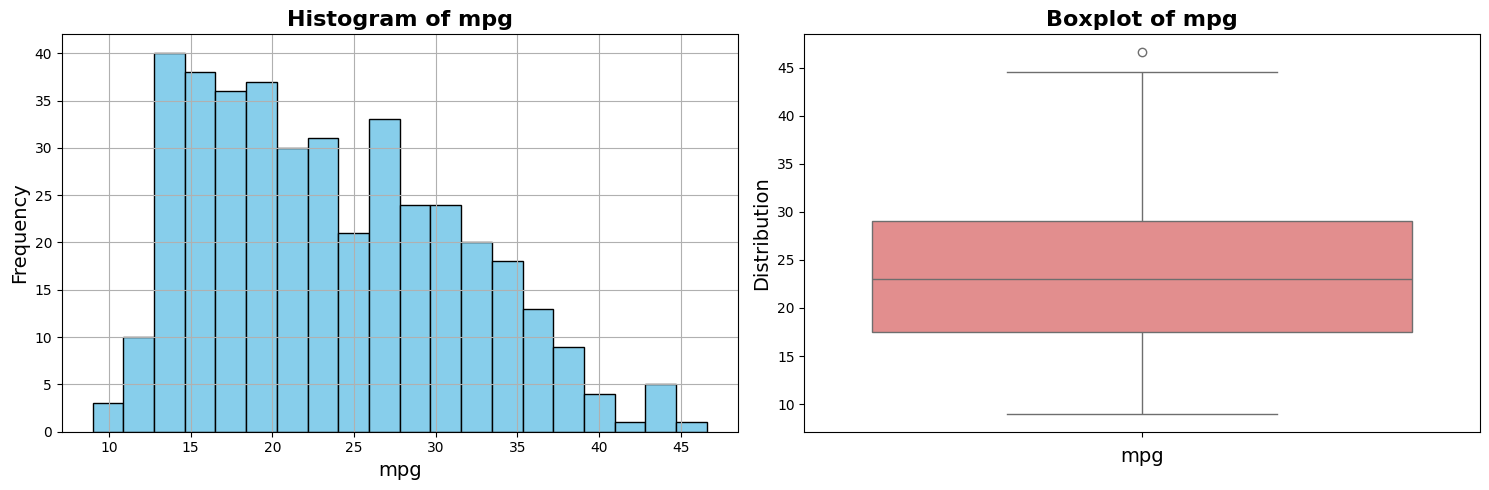

Skew: 0.53


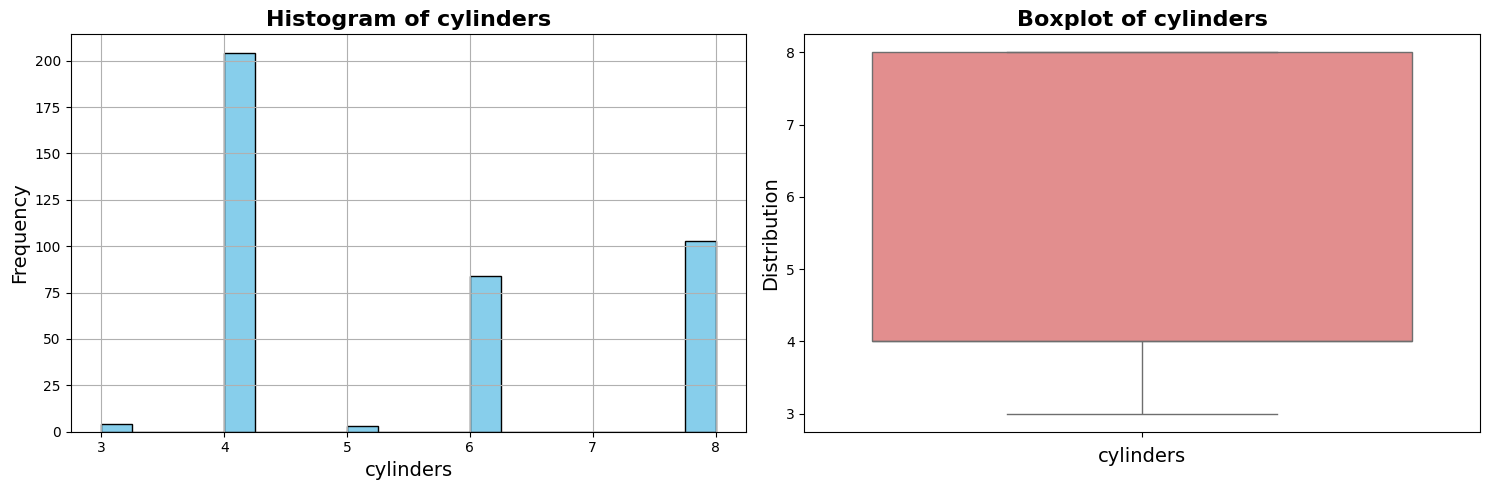

In [ ]:
result=df.select_dtypes(include='number')
cont_cols=list(result)
for col in cont_cols:
  print('Skew:',round(df[col].skew(),2))
  plt.figure(figsize=(15,5))

  plt.subplot(1,2,1)
  plt.title(f'Histogram of {col}',fontsize=16,fontweight='bold')
  df[col].hist(bins=20,color='skyblue',edgecolor='black')
  plt.xlabel(col,fontsize=14)
  plt.ylabel('Frequency',fontsize=14)

  plt.subplot(1,2,2)
  plt.title(f'Boxplot of {col}',fontsize=16,fontweight='bold')
  sns.boxplot(df[col],color='lightcoral',)
  plt.xlabel(col,fontsize=14)
  plt.ylabel('Distribution',fontsize=14)

  plt.tight_layout()
  plt.show()


**Observation**
* mpg is right-skewed with most cars in 15-30 range.
* Most of the cars has either 4 cylinders or 8 cylinders.
* Displacement, horsepower and weight are right-skewed, reflecting dominance of heavy cars in early days of American market.
* Acceleration has a normal distribution around 15 secs.
* Model year of the car is between 1970-1982 in the dataset.

In [ ]:
# Pairwise relationship between different features
sns.pairplot(df)
plt.show()

In [ ]:
features = ["mpg", "displacement", "horsepower", "weight", "acceleration", "model year"]
fig,axes=plt.subplots(nrows=2,ncols=3,figsize=(15,15))
axes=axes.flatten()

for i,col in enumerate(features):
  df.boxplot(column=col,by="cylinders",ax=axes[i],grid=True)
  axes[i].set_title(col, fontsize=12, fontweight='bold')
  axes[i].set_xlabel("Cylinders", fontsize=11)
  axes[i].set_ylabel(col, fontsize=11)

plt.suptitle("Feature Distribution By Number of Cylinders",fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()


**Observation**
* The 8 Cylinder cars are distinctly heavier, larger and more powerful.
* The 4 cylindes are newer model produced after 1975 and are geared towards fuel efficiency after the oil crisis in the world.

###**Correlation Matrix Among Different Variables**

In [ ]:
# Heatmap showing the correlation matrix
plt.figure(figsize=(15,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation matrix',fontsize=16)
plt.show()

**Observation**


*   The variable weight has a high positive correlation with cylinders, displacement and horsepower. This means the heavier cars tend to have more cylinders, large engine size and higher horsepower.
*   The variable mpg has a positive correlation with model year and acceleration. This shows the new cars and cars with higher acceleration have better fuel economy.
* The variable mpg has a high negative corelation with cylinders, displacement, horsepower and weight. It suggest that the fuel efficiency decreases with increase in engine size or number of cylinders or weight of the cars.
* The variable model year and acceleration is negatively correlated to cylinders,horsepower,weight and displacement. So the newer cars are produced with few cylinders, small engine size and less horsepower.
* The variable acceleration has a weak correlation accross the board. It has an independent dimension.

### **Scaling the data**

In [ ]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)
scaled_data=pd.DataFrame(scaled_data,columns=df.columns)
scaled_data.head()

## **Principal Component Analysis**

In [ ]:
# Defining the number of principal components to generate
n=scaled_data.shape[1]

# Finding Principal component of the data
pca=(PCA(n_components=n,random_state=1))
df_pca=pd.DataFrame(pca.fit_transform(scaled_data))
df_pca1=pd.DataFrame(df_pca)

# The percentage of variance explained by each principal component
exp_var=pca.explained_variance_ratio_
print(exp_var)

In [ ]:
# Print the cumulative sum
print(exp_var.cumsum())

In [ ]:
# PCA Summary
pca_summary = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(exp_var))],
    'Explained Variance': exp_var,
    'Cumulative Variance': exp_var.cumsum()
})

print(pca_summary)

In [ ]:
# Finding the least number of components that can explain more than 90% variance
sum=0
for ix,i in enumerate(exp_var):
  sum=sum+i
  if(sum>0.9):
    print("Number of PC that explains at least 90% variance:",ix+1)
    break

**Visualization of PCA**

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.title('Explained Variance per Component',fontsize=16,fontweight='bold')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance(%)')
plt.bar(range(1,len(exp_var)+1),exp_var)

plt.subplot(1,2,2)
plt.plot(range(1,len(exp_var)+1),exp_var.cumsum(),marker='o',linestyle='-',color='maroon')
plt.title("Cumulative Explained Variance",fontsize=16,fontweight='bold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance(%)")

plt.tight_layout()
plt.show()

**Observation**
* PC1 alone explains 71.6% of total variance which is very high for the 7 feature dataset.
* PC2 is 12.3 and PC3 is 10.4%.
* The first three principal component corresponds to a cumulative variance of 94.2% which well above the 80% threshold value.
* Hence the remaining 4 components can be safely discarded.

**PCA Loading**

In [ ]:
pca.components_

In [ ]:
# Making a new dataframe with first 3 principal components as columns and original features as indices
cols=['PC1','PC2','PC3']
data_pca = pd.DataFrame(np.round(pca.components_[:3,:], 2), index = cols, columns = scaled_data.columns)

print(data_pca.T)

#### **Interpret the coefficients of the first three principal components from the below DataFrame**

In [ ]:
def color_negative_red(val):
    if val < 0: return 'color :red'
    elif val >0.40: return 'color : blue'
    else: return 'color : black'

data_pca.T.style.map(color_negative_red)

**Observations**
* PC1 is all about engine size, power and fuel efficiency. The cylinders(0.42), horsepower(0.42), displacement (0.43) and weight (0.41) shows strong positive loading. The feature mpg has a negative loading. This means the heavier/powerful the car, the fuel efficiency is less
* PC2 focuses on completely different trend time. Because the model year dominates with score of 0.91. This highlights PC2 captures how new the car is in the dataset
* PC3 focuses heavily on car's performance dynamics - acceleration of the car. Acceleration has massive positive loading(0.89) with a moderate positive loading of weight(0.28). The horsepower(-0.17) and mpg(-0.26) shows a moderate negative loading. PC3 captures something both PC1 and PC2 missed. This shows a car can be fast without being large

In [ ]:
print(data_pca.columns)

In [ ]:
print(data_pca.T)

#### **Visualize the data in 2 dimensions using the first two principal components**



In [ ]:
plt.figure(figsize = (7,7))
sns.scatterplot(x=df_pca1[0],y=df_pca1[1])
plt.title('PC1 Vs PC2',fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Visualizing the data with Hue in the scatter plot**


In [ ]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
plt.title('PC1 Vs PC2 - Colored by Cylinder',fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
sns.scatterplot(x = df_pca1[0],y = df_pca1[1],palette='viridis',hue=df.cylinders)
plt.subplot(1,2,2)
plt.title('PC1 Vs PC2 - Colored by Model Year',fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")
sns.scatterplot(x = df_pca1[0],y = df_pca1[1],palette='plasma',hue=df['model year'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Observations**
* There is clear separation in three clusters. The 4 cylinder cars(fuel efficient) is represented in the left side of the plot. The 8 cylinder cars(Large & Powerful) is represented in the right side of the plot.
* The new cars sits high on PC2 clearly suggesting it captures the model year.

## **t-SNE**

In [ ]:
tsne=TSNE(random_state=1)
df_tsne=tsne.fit_transform(scaled_data)

In [ ]:
df_tsne.shape

(398, 2)

In [ ]:
df_tsne=pd.DataFrame(df_tsne,columns=['Component 1','Component 2'])

In [ ]:
df_tsne.head()

,Component 1,Component 2
0,36.707752,-2.108404
1,37.192513,-0.058722
2,37.241322,-1.185374
3,36.654381,-1.296686
4,37.348392,-1.658431


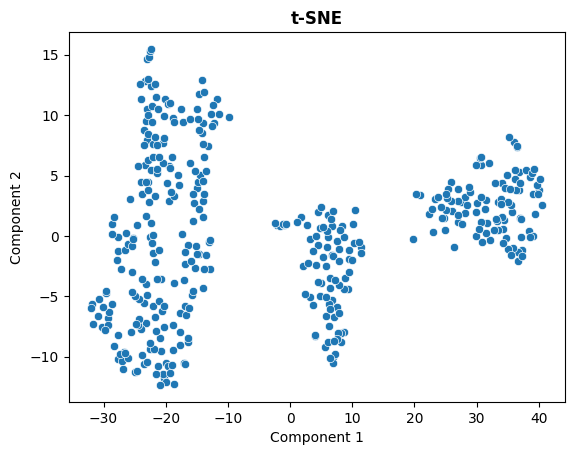

In [ ]:
sns.scatterplot(x=df_tsne.iloc[:,0],y=df_tsne.iloc[:,1])
plt.title('t-SNE',fontweight='bold')
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

**t-SNE Visualization colored by different features of car**

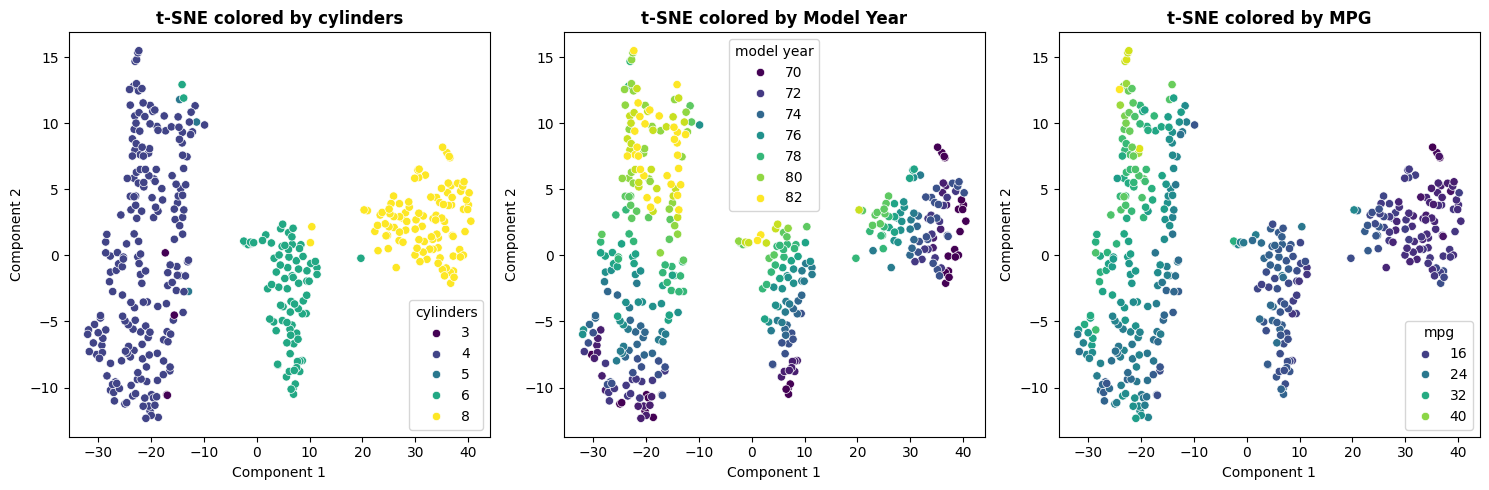

In [ ]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.title('t-SNE colored by cylinders',fontweight='bold')
sns.scatterplot(x=df_tsne.iloc[:,0],y=df_tsne.iloc[:,1],hue=df.cylinders,palette='viridis')
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.subplot(1,3,2)
plt.title('t-SNE colored by Model Year',fontweight='bold')
sns.scatterplot(x=df_tsne.iloc[:,0],y=df_tsne.iloc[:,1],hue=df['model year'],palette='viridis')
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.subplot(1,3,3)
plt.title('t-SNE colored by MPG',fontweight='bold')
sns.scatterplot(x=df_tsne.iloc[:,0],y=df_tsne.iloc[:,1],hue=df.mpg,palette='viridis')
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.tight_layout()
plt.show()

**Observations**
* Three well separated clusters correspondong to 4,6,8 cylinders are shown in left plot.
* The center plot is on model year. The upper gradient represents the new model where as the lower represent the oldest.
* The 4 cylinder cluster is green(high MPG) and 8 cylinder cluster is purple(low MPG) which matches the PC1.

**Both t-sne and PCA analysis tells a consistent story.The dominant structure is determined by number of cylinders, with model year as a secondary factor in each group.**

In [ ]:
# Assignment of clusters into three different groups
def grouping(x):
  first_component=x['Component 1']
  second_component=x['Component 2']
  if (first_component>=12) and (second_component>=-5) :
    return 'group_1'
  elif (first_component<=12) and (first_component<-5):
    return 'group_2'
  else:
    return 'group_3'

In [ ]:
df_tsne['groups']=df_tsne.apply(grouping,axis=1)


In [ ]:
print(df_tsne)

     Component 1  Component 2   groups
0      36.707752    -2.108404  group_1
1      37.192513    -0.058722  group_1
2      37.241322    -1.185374  group_1
3      36.654381    -1.296686  group_1
4      37.348392    -1.658431  group_1
..           ...          ...      ...
393   -14.034748     4.542985  group_2
394   -22.320072    15.480506  group_2
395   -19.144842     3.642219  group_2
396   -14.642265     8.776230  group_2
397   -14.726803     9.692693  group_2

[398 rows x 3 columns]


<Axes: xlabel='Component 1', ylabel='Component 2'>

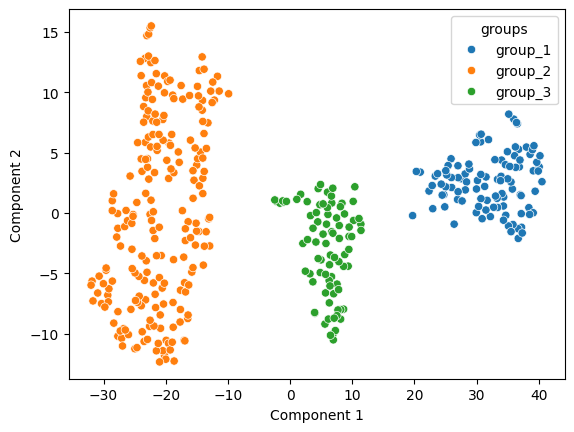

In [ ]:
sns.scatterplot(x=df_tsne.iloc[:,0],y=df_tsne.iloc[:,1],hue=df_tsne.iloc[:,2])

In [ ]:
df['groups']=df_tsne['groups']

#### **Visualize the clusters w.r.t different variables using scatter plot and box plot**

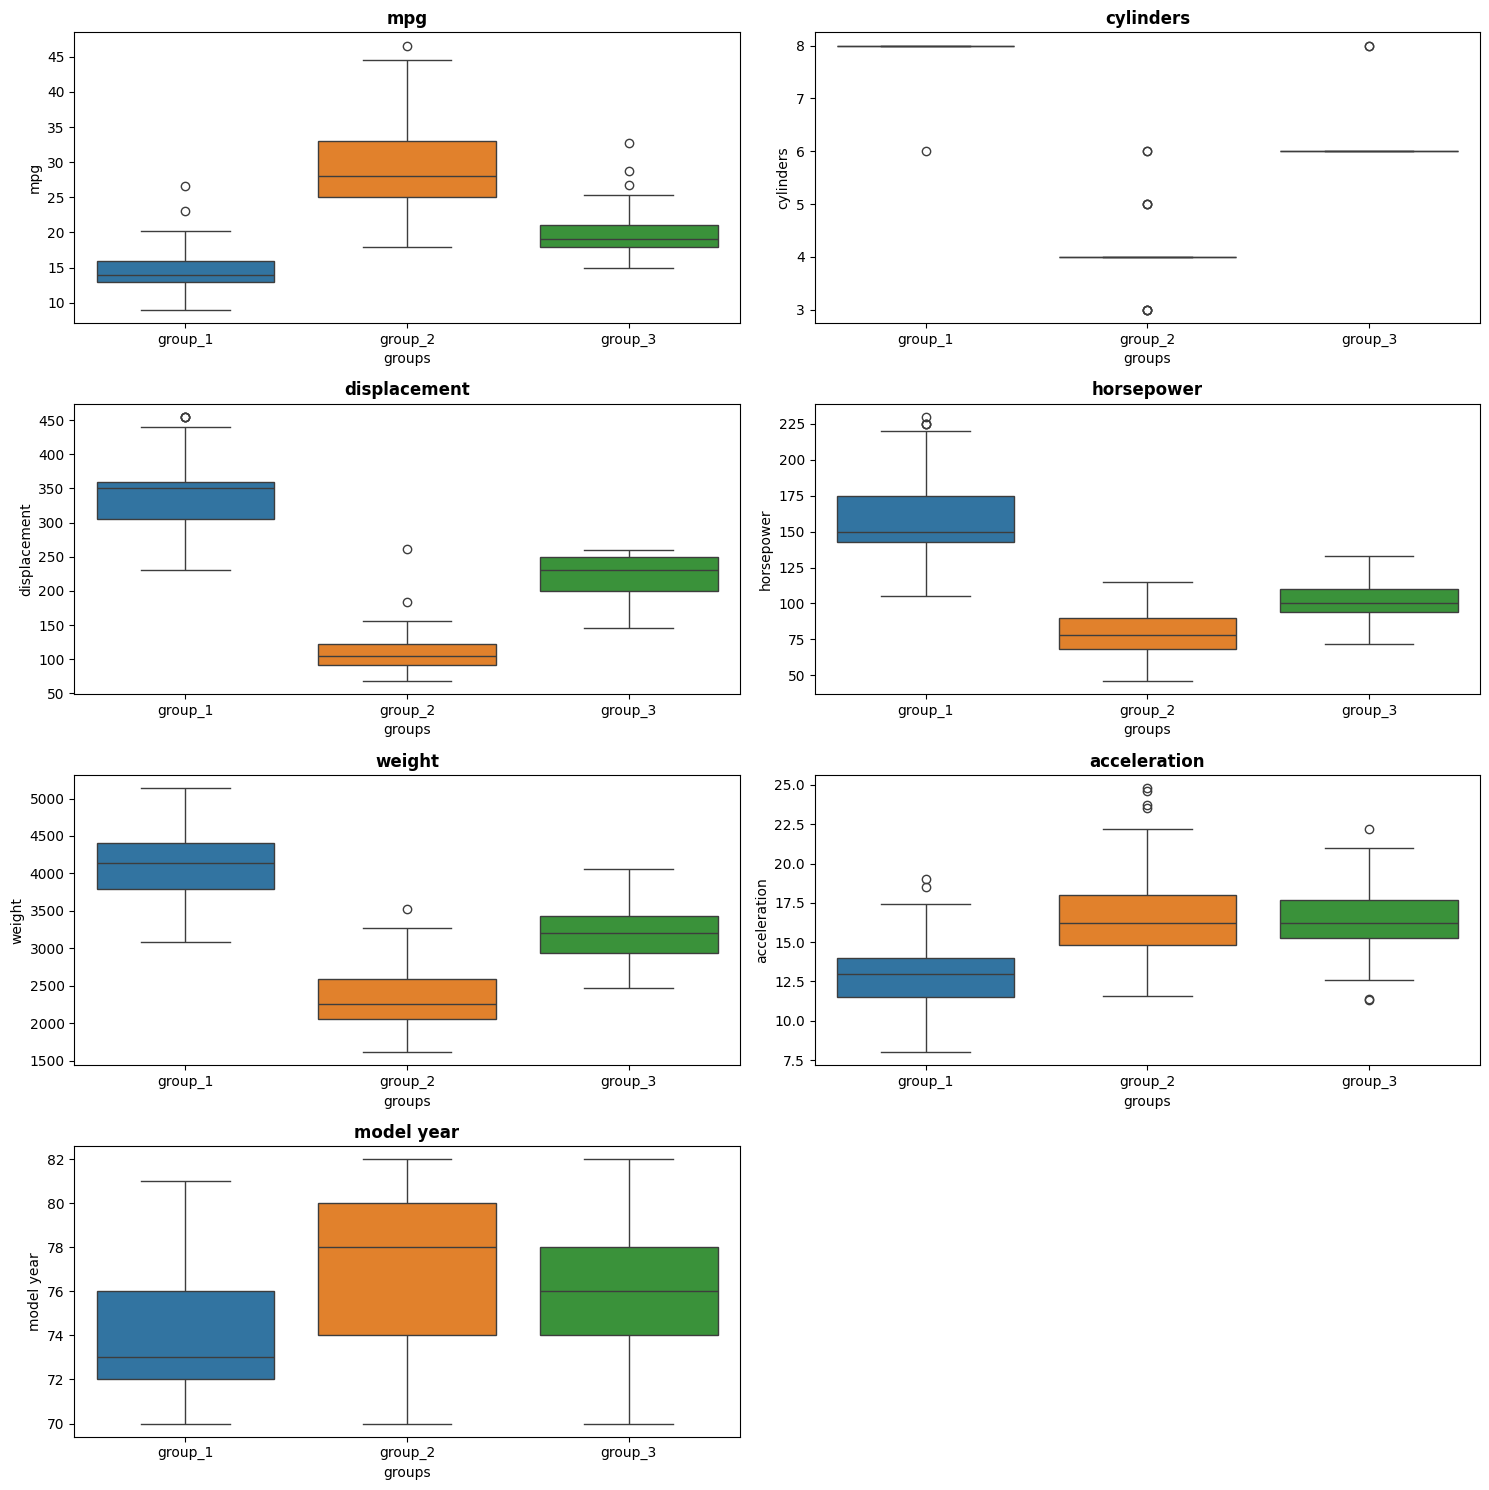

In [ ]:
all_col=df.columns.tolist()
plt.figure(figsize=(15,15))
for i,variable in enumerate(all_col):
  if i==7:
    break
  plt.subplot(4,2,i+1)
  sns.boxplot(x=df['groups'],y=df[variable],hue=df['groups'])
  plt.tight_layout()
  plt.title(variable,fontweight='bold')
plt.show()



In [ ]:
# Transferring the t_sne results to the dataset copy to understand the cluster along with car names
df_data=newData.copy()
df_data['groups']=df_tsne['groups']
df_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,groups
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu,group_1
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320,group_1
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite,group_1
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst,group_1
4,17.0,8,302.0,140,3449,10.5,70,ford torino,group_1


In [ ]:
# List the group 1 cluster
df_data[df_data['groups']=='group_1'].head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,groups
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu,group_1
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320,group_1
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite,group_1
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst,group_1
4,17.0,8,302.0,140,3449,10.5,70,ford torino,group_1


In [ ]:
# List the group 2 cluster

df_data[df_data['groups']=='group_2'].head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,groups
14,24.0,4,113.0,95,2372,15.0,70,toyota corona mark ii,group_2
18,27.0,4,97.0,88,2130,14.5,70,datsun pl510,group_2
19,26.0,4,97.0,46,1835,20.5,70,volkswagen 1131 deluxe sedan,group_2
20,25.0,4,110.0,87,2672,17.5,70,peugeot 504,group_2
21,24.0,4,107.0,90,2430,14.5,70,audi 100 ls,group_2


In [ ]:
# List the group 3 cluster

df_data[df_data['groups']=='group_3'].head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,groups
15,22.0,6,198.0,95,2833,15.5,70,plymouth duster,group_3
16,18.0,6,199.0,97,2774,15.5,70,amc hornet,group_3
17,21.0,6,200.0,85,2587,16.0,70,ford maverick,group_3
24,21.0,6,199.0,90,2648,15.0,70,amc gremlin,group_3
33,19.0,6,232.0,100,2634,13.0,71,amc gremlin,group_3


**Observations**

*   The 7 feature dataset can be reduced to 3 Prinicipal components retaining 94.4% information
* The engine size and fuel efficiency are not independent. They form a latent structure of PC1
* The t-SNE forms 3 natural clusters. The 4 cyclinder cars are efficient and newer cars. The 6 cylinder cars are with reasonable fuel efficiency and 8 cylinder cars are older and powerful ones.
* Model year is independent of engine size
* Acceleration is independent trait. How fast does the car speed doesn't depend only on age and size.

## **Actionable Insights and Recommendations**


####**Group 1:** ####

**Insight**
* In our analysis, Group 1 clearly represents the classic American V8 "Muscle"/Heavy Passenger cars like plymouth satellite, chevrolet chevelle malibu.
* They are mostly pre 1977 model. They are known for high displacement big block or small engine cars.
* They traded fuel economy for pure American performance.

**Recommendation**

* Create Campaigns targeting muscle or car enthusiast and collectors.
* Slogans celebrating golden era of automotive history triggering nostalgia will help in sales.
* Partnering with a local classic car club and establish a presence in the automobile auction will attract serious active buyers.
* Use platform specific digital marketing( vintage forums) to reach out serious buyers.

#### **Group 2:** ####

**Insight**
* The Group 2 represents the exact opposite of Group 1.
* They are lightweight and highly fuel efficient cars like toyota corona, audi 100 ls. The label "imported cars" was loved by the American people.
* High fuel efficiency helped the American family during the oil crisis.


**Recommendations**
* Create Campaigns targeting Japanese/European car collectors and Eco-conscious commuters.
* Slogans celebrating the fuel-crisis era engineering, international styling,low maintenance with high usablity will reinforce unique vehicle hertiage and marketing appeal
* Use platform specific digital marketing( vintage forums) to reach out serious buyers.

#### **Group 3:** ####

**Insight**
* Group 3 represents practical middle ground of 1970's Domestic 6 cylinder compact commuter segment
* Cars like Plymouth Duster, Ford Maverick belongs to mid-tier efficiency with domestic smanufacturing simplicity.

**Recommendations**
* Create campaigns targeting the niche collectors who value cultural nostalgia, unique aesthetics or entry level collectors.
* Slogans focusing on affordable vinatge style, pop culture appeal and daily use will increase the marketing appeal.
* Use platform specific digital marketing( vintage forums) to reach out serious buyers.



## **Limitations** ##
* The vintage car purchase is based on collectability, aesthetic value and historic significance rather than daily commuter value. The data lacks several essential dimensions to optimize downstream marketing and sales processes.
* The dataset contains no historical pricing which is a key factor for buyers.
* Vintage cars pricing fluctuates heavily on restoration cost and the dataset has no data about it and important factor for buyers.

## **Conclusion** ##
The analysis successfully applied PCA and t-SNE to Auto MPG dataset. The key takeway is the vintage automobile is driven by three primary dimensions: engine size vs fuel efficiency (PC1 : 71.6%), model modernity (PC2 : 12.4%) and acceleration ability(PC3 :10.4%). Both techniques converge to the same conclusion. The cylinder count is the important grouping variable that separates into three distinct clusters. SecondLife can leverage this insight to streamline inventory classification, improve pricing accuracy and design targeted marketing campaigns.
